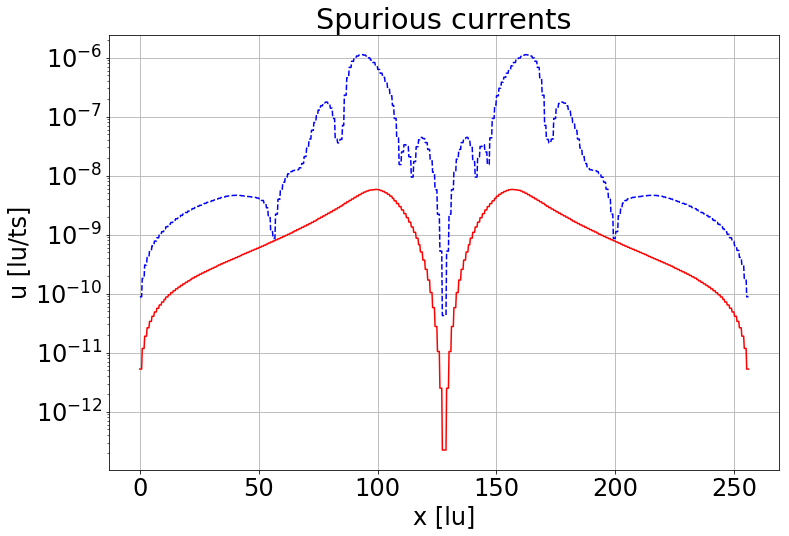

In [4]:

import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv

rho_ratio = '100'
v = '01666'

folder_path = os.path.join("../data_for_plots",
                           "moving_vs_resting_bubble",
                           "line_data_rho%s_v%s_circular_Ux001" % (rho_ratio, v))

frame_n = 999  # last time-frame


frame_cm = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % frame_n), delimiter="\t")
frame_mrt = pd.read_csv(os.path.join(folder_path, "cm_resting_tau.%d.csv" % frame_n), delimiter="\t")
# frame_mrt = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % frame_n), delimiter="\t")

u_cm = np.sqrt(frame_cm['U:0']*frame_cm['U:0']+frame_cm['U:1']*frame_cm['U:1'])
u_mrt = np.sqrt(frame_mrt['U:0']*frame_mrt['U:0']+frame_mrt['U:1']*frame_mrt['U:1'])


# make plot
plt.rcParams.update({'font.size': 24})
plt.figure(figsize=(12, 8))

plt.semilogy(frame_cm['arc_length'], u_cm, color="red", marker="", linestyle="-")#, label='current model')
plt.semilogy(frame_mrt['arc_length'], u_mrt, color="blue", marker="", linestyle="--")#, label='MRT')
#
# plt.plot(frame_cm['arc_length'], u_cm, color="red", marker="", linestyle="-", label='current model')
# plt.plot(frame_mrt['arc_length'], u_mrt, color="blue", marker="o", linestyle='-',markevery=100, label='MRT')

plt.xlabel(r'x [lu]')
plt.ylabel(r'u [lu/ts]')

plt.title('Spurious currents')
plt.grid(True)
plt.legend()


# plt.text(0.0, 5E-6, r'$\rho^* = %s$' % rho_ratio)
fig = plt.gcf()  # get current figure
fig.savefig('spurious_currents_cm_vs_cm_tau_rho%s_v%s.png' % (rho_ratio, v))
plt.show()
